## Importing the libraries

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import json

## Importing the dataset

In [2]:
df = pd.read_csv("../../dataSet/marketing_and_sales_clean.csv")

## Splitting the dataset into the Training set and Test set

In [3]:
X = df[["TV", "Radio", "Influencer", "Social Media"]].values
y = df["Sales"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

## Polynomial features

In [4]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

## Training

In [5]:
lm = LinearRegression()
lm.fit(X_train_poly, y_train)

LinearRegression()

In [6]:
print('Coefficients: \n', lm.coef_)

Coefficients: 
 [ 3.55957229e+00  7.32848099e-03  1.99727542e-01  1.23850504e-02
  1.98315023e-04  2.80379293e-06 -4.88018747e-03 -2.81104046e-03
 -6.96818886e-04  8.89345490e-03  1.20943327e-03 -3.01192155e-02
  2.05279071e-02  8.24571704e-03]


## Prédiction

Text(0, 0.5, 'Predicted Y')

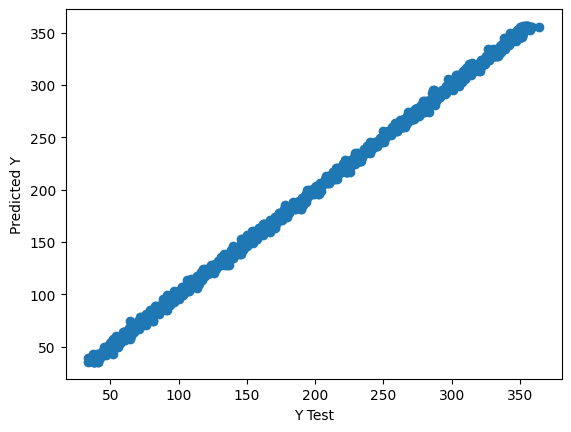

In [7]:
predictions = lm.predict(X_test_poly)
plt.scatter(y_test,predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

## Regression Evaluation Metrics

In [12]:
MAE = metrics.mean_absolute_error(y_test, predictions)
MSE = metrics.mean_squared_error(y_test, predictions)
RMSE = metrics.root_mean_squared_error(y_test, predictions)
R2 = metrics.r2_score(y_test, predictions)
print(f"MAE : {MAE}\nMSE : {MSE}\nRMSE : {RMSE}\nR2 : {R2}\n")
with open('../saved_models/polynomial_linear_regression/metrics.json', 'w') as f:
    f.write(json.dumps({"MAE":MAE, "MSE":MSE, "RMSE":RMSE, "R2":R2}))

MAE : 2.389778566741502
MSE : 8.979274621239423
RMSE : 2.996543779296312
R2 : 0.9989702261036817



## Export model

In [9]:
import pickle
import os
from sklearn.pipeline import Pipeline

os.makedirs('../saved_models/polynomial_linear_regression', exist_ok=True)

# Sauvegarde en Pipeline pour permettre l'inférence directe depuis les features brutes
model_pipeline = Pipeline([
    ('poly', poly),
    ('lm', lm)
])

with open('../saved_models/polynomial_linear_regression/model.pkl', 'wb') as f:
    pickle.dump(model_pipeline, f)